# Detection and Removal of outliers using Z-Score

### Loading and visualizing dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('E:/Dataset/placement.csv')

In [24]:
df.shape

(1000, 3)

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


Text(0.5, 1.0, 'Placement exam marks column')

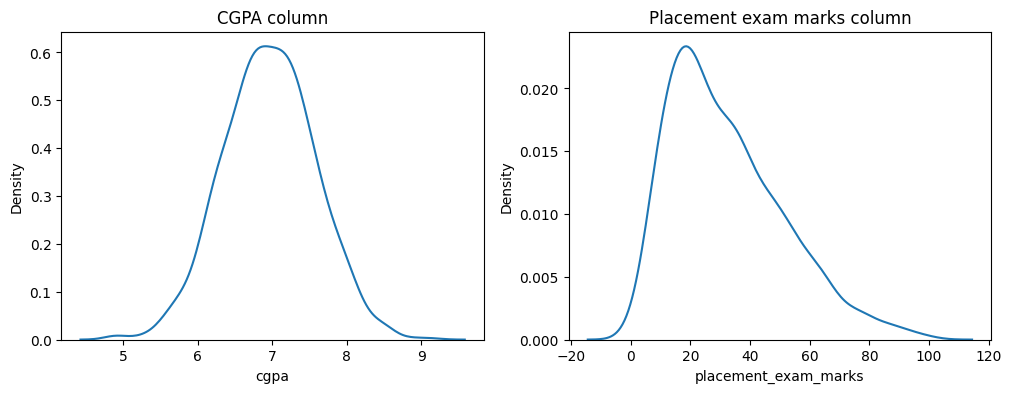

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(121)
sns.kdeplot(df['cgpa'])
plt.title('CGPA column')

plt.subplot(122)
sns.kdeplot(df['placement_exam_marks'])
plt.title('Placement exam marks column')

#### - Data is normally distributed in CGPA column but skewed data in Placement exam so we can apply z-score only on CGPA column

In [10]:
print(f'Mean of CGPA column {df['cgpa'].mean()}')
print(f'Standard Deviation of CGPA column {df['cgpa'].std()}')
print(f'Minimum of CGPA column {df['cgpa'].min()}')
print(f'Maximum of CGPA column {df['cgpa'].max()}')

Mean of CGPA column 6.96124
Standard Deviation of CGPA column 0.6158978751323894
Minimum of CGPA column 4.89
Maximum of CGPA column 9.12


### Finding outliers

In [13]:
min_value = df['cgpa'].mean() - 3*df['cgpa'].std()
max_value = df['cgpa'].mean() + 3*df['cgpa'].std()

print(f'Minimum allowed : {min_value}')
print(f'Maximum allowed : {max_value}')

Minimum allowed : 5.113546374602832
Maximum allowed : 8.808933625397168


In [23]:
# Finding outliers

df[(df['cgpa']<min_value) | (df['cgpa']>max_value)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### Trimming

In [35]:
new_df = df[(df['cgpa']>min_value) & (df['cgpa']<max_value)]
new_df.sample(4)

,cgpa,placement_exam_marks,placed
862,6.04,37.0,1
434,7.01,5.0,0
939,6.98,41.0,0
441,7.80,15.0,1


In [34]:
new_df.shape

(995, 3)

#### Using z-score value

In [36]:
df['cgpa_Z-Score'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [38]:
df.sample(3)

,cgpa,placement_exam_marks,placed,cgpa_Z-Score
435,7.45,37.0,0,0.793573
476,6.83,34.0,0,-0.213087
242,5.99,44.0,0,-1.576950


In [43]:
# Outliers
df[(df['cgpa_Z-Score']>3) | (df['cgpa_Z-Score']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_Z-Score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [45]:
new_df1 = df[(df['cgpa_Z-Score']>-3) & (df['cgpa_Z-Score']<3)]

In [46]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


### Capping

In [48]:
upper_limit = max_value
lower_limit = min_value

print(upper_limit)
print(lower_limit)

8.808933625397168
5.113546374602832


In [49]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [52]:
df.shape

(1000, 4)

In [56]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64